# 🐍 Python Level 3 - Advanced course
## Class 1 — Databases with SQLite
### 📝 Practice Exercises

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">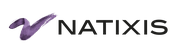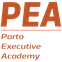</div>

---

---

Work through the sections in order — the difficulty increases as you go.

| Section | Difficulty | Topics |
|---------|------------|--------|
| A | 🟢 Warm-up | connect, create, insert, select |
| B | 🟡 Core practice | `WHERE`, `ORDER BY`, `LIMIT`, placeholders |
| C | 🟠 Applied | `UPDATE`, `DELETE`, `GROUP BY` |
| D | 🔴 Challenge | a small store, and pandas both ways |

> ⚠️ **Run the cells in order, once each.** A1 clears the table and A2 fills it. If you run A2
> twice you will have fourteen books and every total afterwards will be wrong. If that happens,
> just run A1 again and carry on.
>
> ⚠️ **`database is locked`?** An earlier change was left unfinished. Restart the session
> (*Runtime → Restart session*) and run the cells again from the top.

> 💡 **Nothing is saved until `connection.commit()`.** If a change seems not to have happened,
> that is almost always why.

> 💡 SQL keywords are written in capitals here — `SELECT`, `FROM`, `WHERE`. That is a
> convention, not a rule: it makes the keywords stand out from your column names.

> 💡 `library.db` is created on Colab's computer, so it disappears when your session ends —
> which is fine, since you build it again in A1. To keep a database for tomorrow, connect to
> `"/content/drive/MyDrive/library.db"` instead.

---

## ⚙️ Setup

Run this cell first.

In [ ]:
import sqlite3
import pandas as pd

books = [
    ("The Long Road",  "Ana Silva",     2019, 720, 24.50, "available"),
    ("Python Basics",  "Bruno Costa",   2023, 180,  19.90, "on loan"),
    ("Atlas of Ports", "Clara Dias",    2015, 640,  45.00, "available"),
    ("Short Stories",  "Ana Silva",     2021,  95,   9.99, "on loan"),
    ("Deep Water",     "Diogo Melo",    2018, 412,  15.50, "available"),
    ("City Lights",    "Bruno Costa",   2022, 260,  22.00, "lost"),
    ("The Quiet Bay",  "Ana Silva",     2020, 330,  18.75, "available"),
]

print("Setup complete:", len(books), "books to load")

---
## 🟢 Section A — Warm-up
### Connect, create, insert, select

> 🕐 Estimated time: 15 min

### Exercise A1 — Connect and create a table

Open a database called `library.db`, make a cursor, and create a table `books` with these
columns: `title` and `author` as `TEXT`, `year` and `pages` as `INTEGER`, `price` as `REAL`,
and `status` as `TEXT`.

Use `CREATE TABLE IF NOT EXISTS`, then clear the table with `DELETE FROM`, then `commit()`.
Print `Table ready`.

Expected output:
```
Table ready
```

> 💡 Both habits matter: `IF NOT EXISTS` so a second run is not an error, and `DELETE FROM` so
> the rows do not pile up.

In [ ]:
# A1

### Exercise A2 — Insert the books

Insert all seven books in **one call** with `executemany()`, then commit and print how many
rows went in.

Expected output:
```
Rows inserted: 7
```

> 💡 One `?` per column — six of them — and the list `books` is already in the right shape.

In [ ]:
# A2

### Exercise A3 — Read everything back

Select every column from `books` and print one row per line.

Expected output:
```
('The Long Road', 'Ana Silva', 2019, 720, 24.5, 'available')
('Python Basics', 'Bruno Costa', 2023, 180, 19.9, 'on loan')
('Atlas of Ports', 'Clara Dias', 2015, 640, 45.0, 'available')
('Short Stories', 'Ana Silva', 2021, 95, 9.99, 'on loan')
('Deep Water', 'Diogo Melo', 2018, 412, 15.5, 'available')
('City Lights', 'Bruno Costa', 2022, 260, 22.0, 'lost')
('The Quiet Bay', 'Ana Silva', 2020, 330, 18.75, 'available')
```

> 💡 Each row comes back as a **tuple**. The prices are decimal numbers (`REAL` in SQL, `float`
> in Python), and Python prints floats in their shortest form: trailing zeros are dropped, but
> one decimal is always kept, so you know it's a float. That's why `24.50` shows as `24.5` and
> `45.00` as `45.0`.

In [ ]:
# A3

### Exercise A4 — Count the rows

Ask the database how many books there are, and print just the number.

Expected output:
```
Books in the table: 7
```

> 💡 `COUNT(*)` comes back as a one-value tuple, so you need `cursor.fetchone()[0]` to get the
> number out of it.

In [ ]:
# A4

---
## 🟡 Section B — Core practice
### `WHERE`, `ORDER BY`, `LIMIT`, placeholders

> 🕐 Estimated time: 25 min

### Exercise B1 — Choose columns and rows

Print the **title and author** of the books that are `available` — title padded to 16.

Expected output:
```
The Long Road   Ana Silva
Atlas of Ports  Clara Dias
Deep Water      Diogo Melo
The Quiet Bay   Ana Silva
```

In [ ]:
# B1

### Exercise B2 — Sort, and take the top few

1. The **three longest** books, with their page counts, longest first
2. Then the **single cheapest** book, printed as the tuple it comes back as

Expected output:
```
The Long Road     720
Atlas of Ports    640
Deep Water        412

Cheapest: ('Short Stories', 9.99)
```

> 💡 `ORDER BY pages DESC LIMIT 3` for the first. For the second, sort `ASC` and use
> `fetchone()` instead of `fetchall()`.

In [ ]:
# B2

### Exercise B3 — Two conditions

Print the title, year and status of books published **in 2020 or later** *and* currently
`available`.

Expected output:
```
('The Quiet Bay', 2020, 'available')
```

> 💡 In SQL it's `AND`. Lowercase `and` works too, but capitals are the convention.
> No brackets are needed around each side.

In [ ]:
# B3

### Exercise B4 — Use a placeholder

Write a function `books_by(author)` that prints the title and year of every book by one author,
title padded to 16. Call it for `"Ana Silva"` and `"Bruno Costa"`, with a blank line between.

Expected output:
```
The Long Road   2019
Short Stories   2021
The Quiet Bay   2020

Python Basics   2023
City Lights     2022
```

> ⚠️ The author must go in as a `?`, never glued into the string. And the values are always a
> **tuple** — `(author,)` with the comma, or Python will not treat it as one.

In [ ]:
# B4

---
## 🟠 Section C — Applied
### `UPDATE`, `DELETE`, `GROUP BY`

> 🕐 Estimated time: 25 min

### Exercise C1 — Update a row

`Python Basics` has been returned. Print its status, change it to `available`, commit, then
print its status again.

Expected output:
```
Before: ('Python Basics', 'on loan')
After : ('Python Basics', 'available')
```

In [ ]:
# C1

### Exercise C2 — Delete rows

The lost book is being written off.

1. First **look**: select the titles where the status is `lost` and print them
2. Then delete them, commit, and print how many rows went
3. Then print how many rows are left

Expected output:
```
Will delete: [('City Lights',)]
Rows deleted: 1
Rows left   : 6
```

> ⚠️ A `DELETE` with no `WHERE` empties the whole table. Selecting first, every time, is the
> habit that stops that ever happening to you.

In [ ]:
# C2

### Exercise C3 — Summarise the whole table

In **one** query, get the number of books, the total pages, the average price and the highest
price, then print them on four lines.

Expected output:
```
Books        : 6
Total pages  : 2377
Average price: 22.27
Dearest      : 45.00
```

> 💡 `SELECT COUNT(*), SUM(pages), AVG(price), MAX(price) FROM books` returns one row with four
> values — unpack it into four variables.

In [ ]:
# C3

### Exercise C4 — Summarise per author

Using `GROUP BY`, print one line per author with how many books they have and their total
pages, most pages first, under a header.

Expected output:
```
author         books   pages
Ana Silva          3    1145
Clara Dias         1     640
Diogo Melo         1     412
Bruno Costa        1     180
```

> 💡 `AS` names a result column: `COUNT(*) AS books`. The lines are
> `f"{author:<14}{number:>6}{pages:>8}"`.

In [ ]:
# C4

---
## 🔴 Section D — Challenge
### A small store, and pandas both ways

> 🕐 Estimated time: 25 min

### Exercise D1 — A borrowing session

Write a helper `show(label)` that prints a label and then every book with its status, ordered
by title, indented by two spaces.

Then: call it with `"BEFORE"`, make three changes — `Deep Water` goes `on loan`,
`Short Stories` comes back `available`, and a new book is added
(`"New Arrival", "Eva Nunes", 2024, 210, 21.50, "available"`) — commit, call it with `"AFTER"`,
and finish with a `GROUP BY` count per status.

Expected output:
```
BEFORE
  Atlas of Ports  available
  Deep Water      available
  Python Basics   available
  Short Stories   on loan
  The Long Road   available
  The Quiet Bay   available

AFTER
  Atlas of Ports  available
  Deep Water      on loan
  New Arrival     available
  Python Basics   available
  Short Stories   available
  The Long Road   available
  The Quiet Bay   available

status       count
available        6
on loan          1
```

> 💡 Writing `show()` as a function is the point — you call it twice and see the difference,
> which is Level 2 Class 1 doing useful work here.

In [ ]:
# D1

### Exercise D2 — pandas both ways

1. Use `pd.read_sql_query()` to pull the `title`, `author`, `pages` and `price` of the
   `available` books into a DataFrame, and print it
2. Print how many there are, and their average price rounded to 2 decimals
3. Add a `value_per_page` column — price divided by pages, rounded to 4 decimals
4. Write that DataFrame into a **new table** `available_books` with `to_sql()`
5. Read the top 3 by `value_per_page` back out with a query, and print them
6. Commit and `close()` the connection

Expected output:
```
            title       author  pages  price
0   The Long Road    Ana Silva    720  24.50
1   Python Basics  Bruno Costa    180  19.90
2  Atlas of Ports   Clara Dias    640  45.00
3   Short Stories    Ana Silva     95   9.99
4   The Quiet Bay    Ana Silva    330  18.75
5     New Arrival    Eva Nunes    210  21.50

Available books : 6
Average price   : 23.27

           title  value_per_page
0  Python Basics          0.1106
1  Short Stories          0.1052
2    New Arrival          0.1024

Closed.
```

> 💡 `to_sql("available_books", connection, if_exists="replace", index=False)` — `replace` makes
> the cell safe to run twice, and `index=False` keeps the row numbers out of the table.

In [ ]:
# D2

---

### 🎉 Well done!

You have now practised every concept from Class 1 of Level 3:

| | Concept | Exercises |
|-|---------|----------|
| ✅ | `connect`, `cursor`, `commit` | A1 |
| ✅ | `CREATE TABLE IF NOT EXISTS` | A1 |
| ✅ | `INSERT` and `executemany` | A2, D1 |
| ✅ | `SELECT` and `fetchall` | A3, B1 |
| ✅ | `COUNT` and `fetchone` | A4, C3 |
| ✅ | `WHERE`, and `AND` | B1, B3 |
| ✅ | `ORDER BY` and `LIMIT` | B2 |
| ✅ | `?` placeholders | B4, C1, C2, D1 |
| ✅ | `UPDATE` | C1, D1 |
| ✅ | `DELETE` | C2 |
| ✅ | `SUM`, `AVG`, `MAX` | C3 |
| ✅ | `GROUP BY` and `AS` | C4, D1 |
| ✅ | `read_sql_query` and `to_sql` | D2 |
| ✅ | `close()` | D2 |

➡️ The solutions notebook will be shared after the class. Try everything first — the point is
the attempt, not the answer.